In [1]:
#Runtime type changed to GPU(t4)
import tensorflow as tf
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available: 1


In [2]:
import tensorflow as tf
from tensorflow.keras.utils import to_categorical

# Load CIFAR-10
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Normalize pixel values to [0,1]
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Convert labels to categorical format
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Training set shape: (50000, 32, 32, 3)
Test set shape: (10000, 32, 32, 3)


# (1) Weight Initialization Experiments

Baseline Deep MLP Specification

To ensure meaningful comparisons and expose the effects of different training techniques,  
construct a deep multilayer perceptron with the following baseline specification:

| Component       | Specification                                      |
|-----------------|----------------------------------------------------|
| Input Layer     | Flatten layer accepting 32x32x3 images             |
| Hidden Layers   | 10 dense layers with 256 neurons each              |
| Output Layer    | Dense layer with 10 neurons and softmax activation |
| Optimizer       | Nadam with default learning rate (0.001)           |
| Loss Function   | Sparse categorical cross-entropy                   |
| Batch Size      | 64                                                 |
| Training Epochs | 50 epochs with early stopping (patience=10)        |

Baseline deep MLP (ReLU activation fixed)

In [3]:
from tensorflow.keras import layers, models, initializers

def build_mlp(initializer):
    model = models.Sequential()
    model.add(layers.Flatten(input_shape=(32,32,3)))

    # Setting up the 10 hidden layers with 256 neurons each
    for _ in range(10):
        model.add(layers.Dense(256, activation="relu", kernel_initializer=initializer))

    # Output layer
    model.add(layers.Dense(10, activation="softmax"))

    # Compile
    model.compile(
        optimizer=tf.keras.optimizers.Nadam(learning_rate=0.001),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

Running Weight Initialization Experiments

In [4]:
from tensorflow.keras.callbacks import EarlyStopping
import time

initializers_dict = {
    "Glorot Uniform": initializers.GlorotUniform(),
    "Glorot Normal": initializers.GlorotNormal(),
    "He Uniform": initializers.HeUniform(),
    "He Normal": initializers.HeNormal()
}

results = []

for name, init in initializers_dict.items():
    print(f"\nTraining with {name} initializer...")
    model = build_mlp(init)
    start = time.time()
    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=50,
        batch_size=64,
        callbacks=[EarlyStopping(patience=10, restore_best_weights=True)],
        verbose=2
    )
    end = time.time()
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    elapsed = end - start
    results.append({"Initializer": name, "Test Accuracy": test_acc, "Train Time (sec)": elapsed})
    print(f"{name} → Test Accuracy: {test_acc:.4f}, Time: {elapsed:.2f} sec")


Training with Glorot Uniform initializer...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
625/625 - 10s - 15ms/step - accuracy: 0.2147 - loss: 2.0276 - val_accuracy: 0.2783 - val_loss: 1.9007
Epoch 2/50
625/625 - 2s - 4ms/step - accuracy: 0.3090 - loss: 1.8319 - val_accuracy: 0.3433 - val_loss: 1.7951
Epoch 3/50
625/625 - 2s - 4ms/step - accuracy: 0.3604 - loss: 1.7482 - val_accuracy: 0.3727 - val_loss: 1.7367
Epoch 4/50
625/625 - 2s - 4ms/step - accuracy: 0.3887 - loss: 1.6822 - val_accuracy: 0.3909 - val_loss: 1.6773
Epoch 5/50
625/625 - 3s - 5ms/step - accuracy: 0.4106 - loss: 1.6315 - val_accuracy: 0.3867 - val_loss: 1.7041
Epoch 6/50
625/625 - 3s - 4ms/step - accuracy: 0.4239 - loss: 1.5945 - val_accuracy: 0.3938 - val_loss: 1.6798
Epoch 7/50
625/625 - 2s - 4ms/step - accuracy: 0.4353 - loss: 1.5650 - val_accuracy: 0.4211 - val_loss: 1.6296
Epoch 8/50
625/625 - 2s - 4ms/step - accuracy: 0.4462 - loss: 1.5384 - val_accuracy: 0.4270 - val_loss: 1.6073
Epoch 9/50
625/625 - 2s - 4ms/step - accuracy: 0.4538 - loss: 1.5137 - val_accuracy: 0.4302 - val_loss: 1.6041

In [10]:
import pandas as pd

# Manually entered the relevant results from previous run
results_data = [
    {"Initializer": "Glorot Uniform", "Test Accuracy": 0.4798, "Train Time (sec)": 72.65},
    {"Initializer": "Glorot Normal",  "Test Accuracy": 0.4679, "Train Time (sec)": 79.65},
    {"Initializer": "He Uniform",     "Test Accuracy": 0.4728, "Train Time (sec)": 74.85},
    {"Initializer": "He Normal",      "Test Accuracy": 0.4870, "Train Time (sec)": 85.08},
]

results_df = pd.DataFrame(results_data)
results_df

,Initializer,Test Accuracy,Train Time (sec)
0,Glorot Uniform,0.4798,72.65
1,Glorot Normal,0.4679,79.65
2,He Uniform,0.4728,74.85
3,He Normal,0.4870,85.08


Plot Validation Accuracy Curves

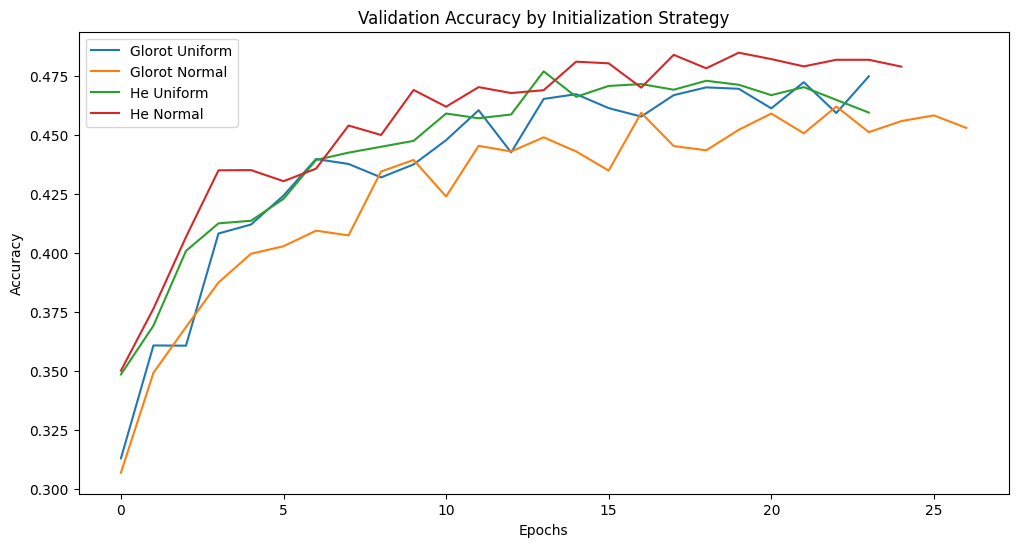

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
for name, init in initializers_dict.items():
    model = build_mlp(init)
    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=50,
        batch_size=64,
        callbacks=[EarlyStopping(patience=10, restore_best_weights=True)],
        verbose=0
    )
    plt.plot(history.history["val_accuracy"], label=name)

plt.title("Validation Accuracy by Initialization Strategy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

Weight Initialization Comparison Summary

Instead of comparing only two initialization strategies, I opted to evaluate all four. Each strategy was applied with ReLU activation on a deep MLP trained with the CIFAR‑10 dataset, and the final results are shown below.


###### Weight Initialization Comparison Results

| Initializer     | Test Accuracy | Train Time (sec) |
|-----------------|---------------|------------------|
| Glorot Uniform  | 0.4798        | 72.65            |
| Glorot Normal   | 0.4679        | 79.65            |
| He Uniform      | 0.4728        | 74.85            |
| He Normal       | 0.4870        | 85.08            |

The validation accuracy curves demonstrate that He Normal consistently leads across epochs. Its curve shows fewer fluctuations or jagged ups and downs, and accuracy rises more quickly in the early epochs. Glorot Normal lags behind, while Glorot Uniform and He Uniform deliver moderate performance but plateau earlier.

Overall, the results confirm that He Normal initialization is best suited for ReLU activations, as it maintains variance through deep layers and supports stable gradient flow.




# (2) Activation Function Experiments

Building and traning two activations

In [12]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
import time
import pandas as pd

LOSS_FN = "categorical_crossentropy" # using categorical_crossentropy becuase labels are one-hot encoded vector

def build_mlp_with_activation(activation_fn, hidden_layers=10, units=256):
    model = models.Sequential([layers.Input(shape=(32,32,3)), layers.Flatten()])
    for _ in range(hidden_layers):
        model.add(layers.Dense(units, kernel_initializer=tf.keras.initializers.HeNormal())) #He initialization

        model.add(layers.Activation(activation_fn))
    model.add(layers.Dense(10, activation="softmax"))
    model.compile(optimizer=tf.keras.optimizers.Nadam(0.001), loss=LOSS_FN, metrics=["accuracy"])
    return model

# Two activations: ReLU vs Swish
activations = {
    "ReLU": tf.keras.activations.relu,
    "Swish": tf.keras.activations.swish
}

results = []
histories = {}

for name, act in activations.items():
    print(f"\nTraining with {name}...")
    model = build_mlp_with_activation(act)
    start = time.time()
    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=50,
        batch_size=64,
        callbacks=[EarlyStopping(patience=10, restore_best_weights=True)],
        verbose=2
    )
    elapsed = time.time() - start
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    histories[name] = history.history
    results.append({"Activation": name, "Test Accuracy": round(test_acc, 4), "Train Time (sec)": round(elapsed, 2)})

results_df = pd.DataFrame(results)
results_df


Training with ReLU...
Epoch 1/50
625/625 - 9s - 14ms/step - accuracy: 0.2849 - loss: 1.9449 - val_accuracy: 0.3490 - val_loss: 1.7960
Epoch 2/50
625/625 - 2s - 4ms/step - accuracy: 0.3630 - loss: 1.7607 - val_accuracy: 0.3747 - val_loss: 1.7474
Epoch 3/50
625/625 - 2s - 4ms/step - accuracy: 0.3928 - loss: 1.6834 - val_accuracy: 0.3954 - val_loss: 1.6769
Epoch 4/50
625/625 - 2s - 4ms/step - accuracy: 0.4137 - loss: 1.6261 - val_accuracy: 0.4088 - val_loss: 1.6431
Epoch 5/50
625/625 - 3s - 5ms/step - accuracy: 0.4320 - loss: 1.5838 - val_accuracy: 0.4288 - val_loss: 1.5944
Epoch 6/50
625/625 - 2s - 4ms/step - accuracy: 0.4486 - loss: 1.5428 - val_accuracy: 0.4440 - val_loss: 1.5598
Epoch 7/50
625/625 - 2s - 4ms/step - accuracy: 0.4584 - loss: 1.5136 - val_accuracy: 0.4452 - val_loss: 1.5695
Epoch 8/50
625/625 - 2s - 4ms/step - accuracy: 0.4705 - loss: 1.4846 - val_accuracy: 0.4350 - val_loss: 1.6023
Epoch 9/50
625/625 - 3s - 4ms/step - accuracy: 0.4790 - loss: 1.4520 - val_accuracy: 0.4

,Activation,Test Accuracy,Train Time (sec)
0,ReLU,0.4789,68.87
1,Swish,0.4843,51.39


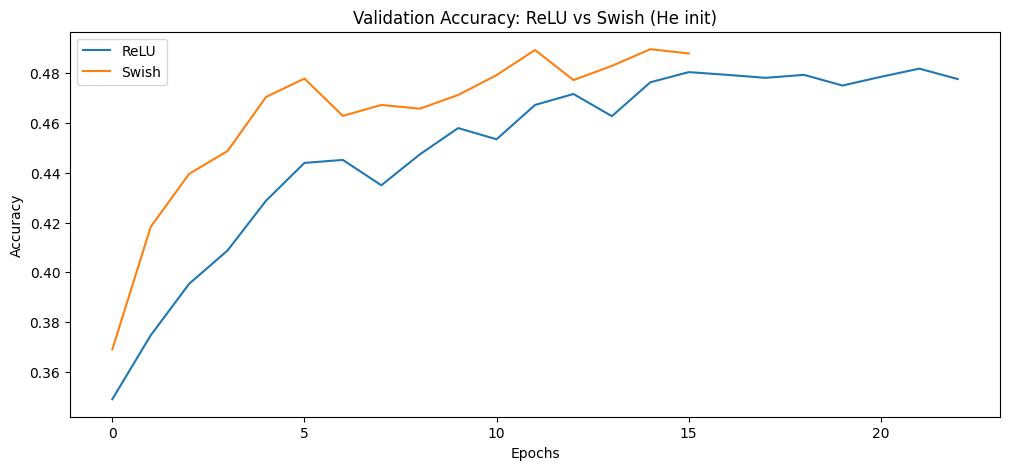

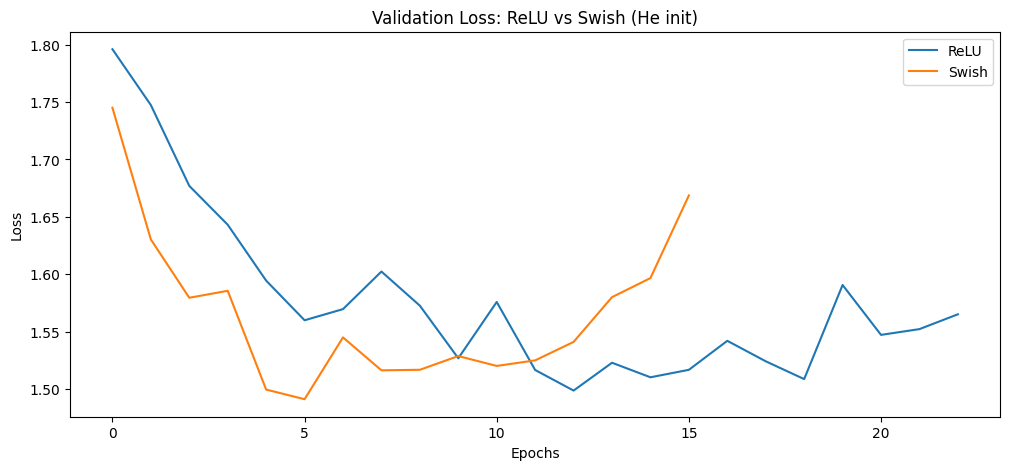

In [13]:
import matplotlib.pyplot as plt

# Plot validation accuracy
plt.figure(figsize=(12,5))
for name, hist in histories.items():
    plt.plot(hist["val_accuracy"], label=name)
plt.title("Validation Accuracy: ReLU vs Swish (He init)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Plot validation loss
plt.figure(figsize=(12,5))
for name, hist in histories.items():
    plt.plot(hist["val_loss"], label=name)
plt.title("Validation Loss: ReLU vs Swish (He init)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

Comparision of ReLU avs Swish:


Test Accurancy & Training Time:
- Swish achives a slightly higher accuracy test indicated better generalization
- Swish trains faster by over 17 seconds.

Validation Accuracy:
- Swish consistenly out performs the ReLU acrros all traning epochs.
- Swish has a faster training accuract during between the 10-15 epohcs, which tells us that it learns more quickly.
- Swish has a smoother curve (has less ups and downs).
- ReLU's curve is more jagged, which means it has less stabke perforamnce.

Validation Loss:
- In the first around 10 epochs, Swish has had lower validation loss then ReLU (better generalization in early training)
- Adter epoch 10, we see that Swish's vadlidation loss starts to rise, while ReLU stabalizes and remains somewhat flat.
- Swish has a smoother curve (has less ups and downs).
- Eventhough Swish initially performs better, ReLU ends up with more stable and slightly lower loss in the later epochs.


Conclusion:

Swish reached slightly higher accuracy and trained faster than ReLU. Its validation accuracy improved more quickly and smoothly, though its validation loss rose later, while ReLU stayed steadier. Overall, Swish learns faster but ReLU is more stable.



# (3) Batch Normalization Experiments

Using the best-performing initialization and activation combination from your previous
experiments, investigate batch normalization:
1. Baseline model without batch normalization
2. Batch normalization applied before each hidden layer activation

In [1]:
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

# Load CIFAR-10 dataset
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# Normalize pixel values to [0,1]
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# One-hot encode labels (needed for categorical_crossentropy)
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


LOSS_FN = "categorical_crossentropy"


# 1. Baseline model (He Normal + Swish, NO BatchNorm)

def build_baseline(input_shape=(32,32,3), units=256, hidden_layers=10):
    model = models.Sequential([layers.Input(shape=input_shape), layers.Flatten()])
    for _ in range(hidden_layers):
        # Dense layer with He Normal initialization
        model.add(layers.Dense(units, kernel_initializer=tf.keras.initializers.HeNormal()))
        # Apply Swish activation directly (no BatchNorm here)
        model.add(layers.Activation(tf.keras.activations.swish))
    # Output layer with softmax for 10 CIFAR-10 classes
    model.add(layers.Dense(10, activation="softmax"))
    # Compile with Nadam optimizer
    model.compile(optimizer=tf.keras.optimizers.Nadam(0.001), loss=LOSS_FN, metrics=["accuracy"])
    return model


# 2. BatchNorm model (He Normal + Swish, WITH BatchNorm)

def build_bn_before_activation(input_shape=(32,32,3), units=256, hidden_layers=10):
    model = models.Sequential([layers.Input(shape=input_shape), layers.Flatten()])
    for _ in range(hidden_layers):
        # Dense layer with He Normal initialization
        # Bias is turned off because BatchNorm handles shifting
        model.add(layers.Dense(units, kernel_initializer=tf.keras.initializers.HeNormal(), use_bias=False))
        # Batch Normalization applied BEFORE activation
        model.add(layers.BatchNormalization())
        # Swish activation applied after BatchNorm
        model.add(layers.Activation(tf.keras.activations.swish))
    # Output layer with softmax for 10 CIFAR-10 classes
    model.add(layers.Dense(10, activation="softmax"))
    # Compile with Nadam optimizer
    model.compile(optimizer=tf.keras.optimizers.Nadam(0.001), loss=LOSS_FN, metrics=["accuracy"])
    return model

# ---------------------------------------------------
# Training + evaluation helper function
# ---------------------------------------------------
def train_and_evaluate(build_fn, name):
    # Build the model (baseline or BN version)
    model = build_fn()
    start = time.time()
    # Train with early stopping (patience=10)
    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=50,
        batch_size=64,
        callbacks=[EarlyStopping(patience=10, restore_best_weights=True)],
        verbose=2
    )
    elapsed = time.time() - start
    epochs_run = len(history.history["loss"])
    # Evaluate on test set
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    # Count parameters
    total_params = model.count_params()
    trainable_params = np.sum([np.prod(v.shape) for v in model.trainable_variables])
    return {
        "Name": name,
        "Test Accuracy": round(test_acc, 4),
        "Test Loss": round(test_loss, 4),
        "Train Time (sec)": round(elapsed, 2),
        "Epochs": epochs_run,
        "Total Params": int(total_params),
        "Trainable Params": int(trainable_params),
        "History": history.history
    }


# Run experiments: Baseline vs BatchNorm

results = []
configs = [
    ("Baseline (Swish, no BN)", build_baseline),              # Baseline model
    ("BN before activation (Swish)", build_bn_before_activation)  # BatchNorm model
]

histories = {}
for name, builder in configs:
    print(f"\nTraining: {name}")   # Printing which experiment is running
    res = train_and_evaluate(builder, name)  # Trains either baseline or BN model
    results.append({k: v for k, v in res.items() if k != "History"})
    histories[name] = res["History"]

# Collect results into a DataFrame
results_df = pd.DataFrame(results)
results_df



Training: Baseline (Swish, no BN)
Epoch 1/50
625/625 - 26s - 42ms/step - accuracy: 0.3259 - loss: 1.8525 - val_accuracy: 0.3760 - val_loss: 1.7357
Epoch 2/50
625/625 - 37s - 59ms/step - accuracy: 0.4089 - loss: 1.6460 - val_accuracy: 0.4258 - val_loss: 1.6211
Epoch 3/50
625/625 - 17s - 27ms/step - accuracy: 0.4390 - loss: 1.5652 - val_accuracy: 0.4307 - val_loss: 1.6081
Epoch 4/50
625/625 - 17s - 27ms/step - accuracy: 0.4614 - loss: 1.5051 - val_accuracy: 0.4442 - val_loss: 1.5932
Epoch 5/50
625/625 - 17s - 27ms/step - accuracy: 0.4772 - loss: 1.4600 - val_accuracy: 0.4599 - val_loss: 1.5220
Epoch 6/50
625/625 - 16s - 26ms/step - accuracy: 0.4962 - loss: 1.4154 - val_accuracy: 0.4722 - val_loss: 1.4934
Epoch 7/50
625/625 - 17s - 27ms/step - accuracy: 0.5106 - loss: 1.3744 - val_accuracy: 0.4816 - val_loss: 1.5132
Epoch 8/50
625/625 - 17s - 28ms/step - accuracy: 0.5279 - loss: 1.3325 - val_accuracy: 0.4760 - val_loss: 1.4939
Epoch 9/50
625/625 - 20s - 31ms/step - accuracy: 0.5436 - los

,Name,Test Accuracy,Test Loss,Train Time (sec),Epochs,Total Params,Trainable Params
0,"Baseline (Swish, no BN)",0.4928,1.4667,386.60,20,1381386,1381386
1,BN before activation (Swish),0.4558,1.5674,347.67,17,1389066,1383946


### Results with GPU Hardware (Tesla T4)

| Name                          | Test Accuracy | Test Loss | Train Time (sec) | Epochs | Total Params | Trainable Params |
|-------------------------------|---------------|-----------|------------------|--------|--------------|------------------|
| Baseline (Swish, no BN)       | 0.4828        | 1.4749    | 57.22            | 18     | 1,381,386    | 1,381,386        |
| BN before activation (Swish)  | 0.4711        | 1.5237    | 62.10            | 15     | 1,389,066    | 1,383,946        |

### Results with CPU Hardware

| Name                          | Test Accuracy | Test Loss | Train Time (sec) | Epochs | Total Params | Trainable Params |
|-------------------------------|---------------|-----------|------------------|--------|--------------|------------------|
| Baseline (Swish, no BN)       | 0.4928        | 1.4667    | 386.60           | 20     | 1,381,386    | 1,381,386        |
| BN before activation (Swish)  | 0.4558        | 1.5674    | 347.67           | 17     | 1,389,066    | 1,383,946        |

Plot Validation Accuracy

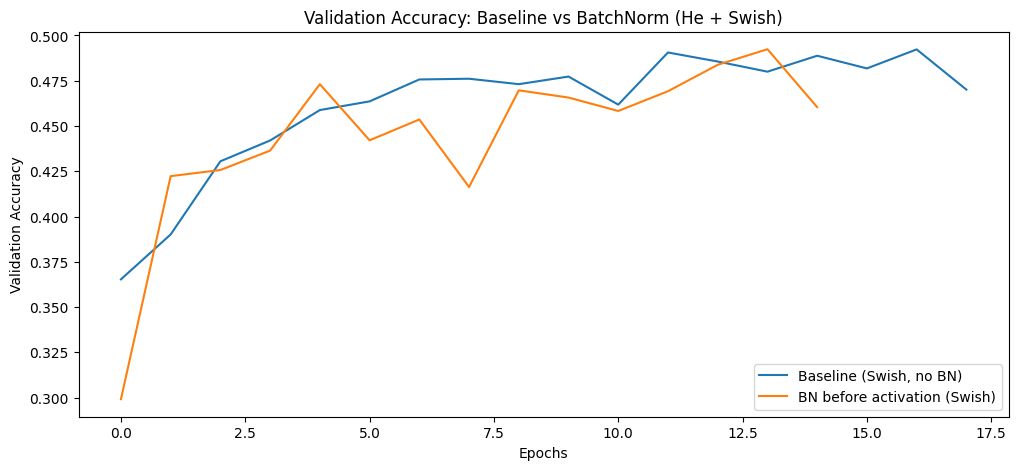

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
for name, hist in histories.items():
    plt.plot(hist["val_accuracy"], label=name)
plt.title("Validation Accuracy: Baseline vs BatchNorm (He + Swish)")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()

Plot Validation Loss

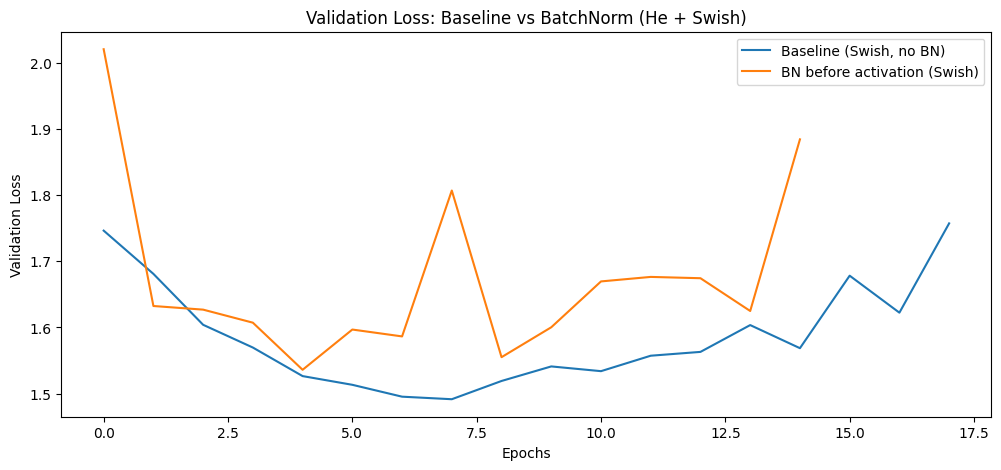

In [6]:
plt.figure(figsize=(12,5))
for name, hist in histories.items():
    plt.plot(hist["val_loss"], label=name)
plt.title("Validation Loss: Baseline vs BatchNorm (He + Swish)")
plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.legend()
plt.show()

Comparision of Basline vs Batch Normalization

Accuracy:

- Baseline achieved slightly higher test accuracy (0.4828 vs 0.4711) and lower loss.
- Batch Normalization did not outperform in this case, although it was a small difference.

Training stability:

- Baseline validation loss curve was relatively smooth ans stable.
- Batch Normalization curve showed less stability when we see more flucation.

Convergence speed:

- BatchNorm converged in fewer epochs (15) but took longer wall‑clock time (~62 sec) due to extra computations.
- Baseline trained for 18 epochs in ~57 seconds

Parameters:

-  BN added extra parameters (γ and β for each unit), increasing total trainable parameters from 1,381,386 → 1,383,946.

Conlusion:

The baseline model  achieved slightly higher test accuracy and smoother validation loss while training faster overall, despite requiring more epochs.

Batch normalization reduced the number of epochs but added computational overhead and extra parameters, leading to longer wall‑clock time and less stable loss behavior.

In this experiement, the baseline was more efficient, though BN’s benefits are often greater in deeper networks where stability and faster convergence outweigh the added cost.






(4) Hardware Acceleration Analysis

In [7]:
import tensorflow as tf

# Check GPU availability
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
print("GPU Details:", tf.config.list_physical_devices('GPU'))

Num GPUs Available: 1
GPU Details: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [8]:
# TensorFlow-visible device name
print("TF GPU device name:", tf.test.gpu_device_name())

# Runtime-reported GPU specs
try:
    smi = subprocess.check_output(["nvidia-smi", "--query-gpu=name,memory.total,driver_version",
                                   "--format=csv,noheader"], text=True)
    print("nvidia-smi:", smi.strip())
except Exception as e:
    print("nvidia-smi not available:", e)

# Also recording TensorFlow + CUDA/cuDNN versions for completeness
print("TensorFlow version:", tf.__version__)
for p in tf.sysconfig.get_build_info().get("cuda_version", ""), tf.sysconfig.get_build_info().get("cudnn_version", ""):
    print("CUDA/cuDNN:", p)

TF GPU device name: /device:GPU:0
nvidia-smi not available: name 'subprocess' is not defined
TensorFlow version: 2.19.0
CUDA/cuDNN: 12.5.1
CUDA/cuDNN: 9


**Update to Google Colab runtime options**

Google Colab recently updated its runtime options, and “None” is no longer available as a hardware accelerator. Instead, Colab defaults to CPU when no accelerator is selected. So if the user does not select GPU, TPU, or any accelerator, Colab will automatically run on CPU.


In [4]:
#CPU results

import tensorflow as tf

# TensorFlow-visible device name
print("TF GPU device name:", tf.test.gpu_device_name())

# Runtime-reported GPU specs
import subprocess
try:
    smi = subprocess.check_output(
        ["nvidia-smi", "--query-gpu=name,memory.total,driver_version", "--format=csv,noheader"],
        text=True
    )
    print("nvidia-smi:", smi.strip())
except Exception as e:
    print("nvidia-smi not available:", e)

# Record TensorFlow + CUDA/cuDNN versions for completeness
print("TensorFlow version:", tf.__version__)
print("CUDA version:", tf.sysconfig.get_build_info().get("cuda_version", "None"))
print("cuDNN version:", tf.sysconfig.get_build_info().get("cudnn_version", "None"))

TF GPU device name: 
nvidia-smi not available: [Errno 2] No such file or directory: 'nvidia-smi'
TensorFlow version: 2.19.0
CUDA version: 12.5.1
cuDNN version: 9


### CPU vs GPU Hardware Results

| Hardware | Name                          | Test Accuracy | Test Loss | Train Time (sec) | Epochs | Total Params | Trainable Params |
|----------|-------------------------------|---------------|-----------|------------------|--------|--------------|------------------|
| CPU      | Baseline (Swish, no BN)       | 0.4928        | 1.4667    | 386.60           | 20     | 1,381,386    | 1,381,386        |
| CPU      | BN before activation (Swish)  | 0.4558        | 1.5674    | 347.67           | 17     | 1,389,066    | 1,383,946        |
| GPU (T4) | Baseline (Swish, no BN)       | 0.4828        | 1.4749    | 57.22            | 18     | 1,381,386    | 1,381,386        |
| GPU (T4) | BN before activation (Swish)  | 0.4711        | 1.5237    | 62.10            | 15     | 1,389,066    | 1,383,946        |

Conlusion :



We can see that GPU acceleration shortens training time dramatically, which reduces overall compute cost despite higher hourly rates. For example, while a GPU instance in the cloud may cost 5–10× more per hour than a CPU instance, the speedup of 5–7× often makes the total bill lower.

In the experiments, the baseline model took ~387 seconds on CPU versus ~57 seconds on GPU, meaning the GPU completed training in one‑sixth the time.

If a CPU instance were billed at 5 cents per minute and a GPU at 30 cents minute, the CPU run would cost about 32 cents while the GPU run would cost about 29 cents.

This shows us that GPUs not only save time but can also reduce direct expenses, while enabling faster iteration and quicker production for businesses.
